# Multivariate Linear Regression (Sklearn)

### Imports


In [26]:
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Dataset 

In [27]:
data = np.loadtxt("housing_data.txt", dtype=float)

X = data[:,: -1]
y = data[:,-1]

In [28]:
X.shape, y.shape

((50, 3), (50,))

### Train Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (40, 3) (40,)
Test shapes: (10, 3) (10,)


### Build Pipeline

In [30]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ("regression", LinearRegression())
])

### Fit The Model 

In [31]:
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


### Predictions

In [32]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [33]:
print(y_test_pred[:5])

[619530.10745371 351958.45720803 323860.67435709 306942.28780999
 233611.99450827]


### Model Evaluation

In [34]:
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

print("model.score:", model.score(X_test, y_test))

RMSE: 85621.23006172582
MAE: 58673.09560849066
R²: 0.6861659956253976
model.score: 0.6861659956253976


### Ploting


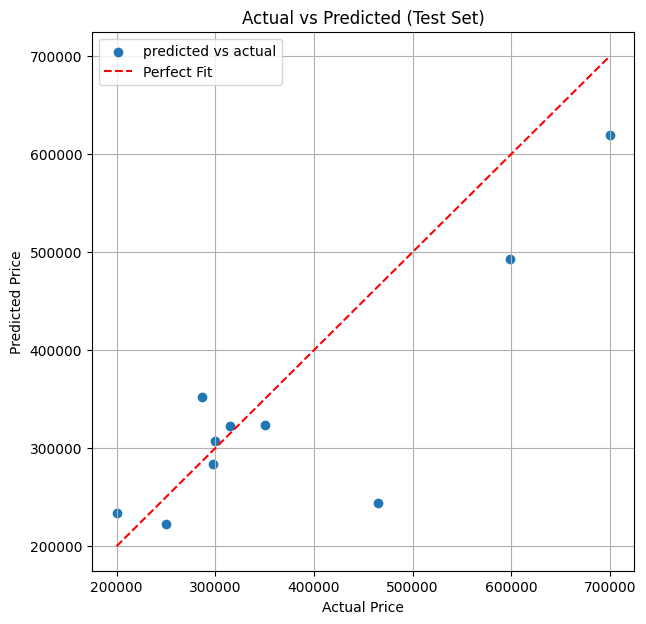

In [35]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_test_pred, label= "predicted vs actual")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Perfect Fit")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

### Residual Plot

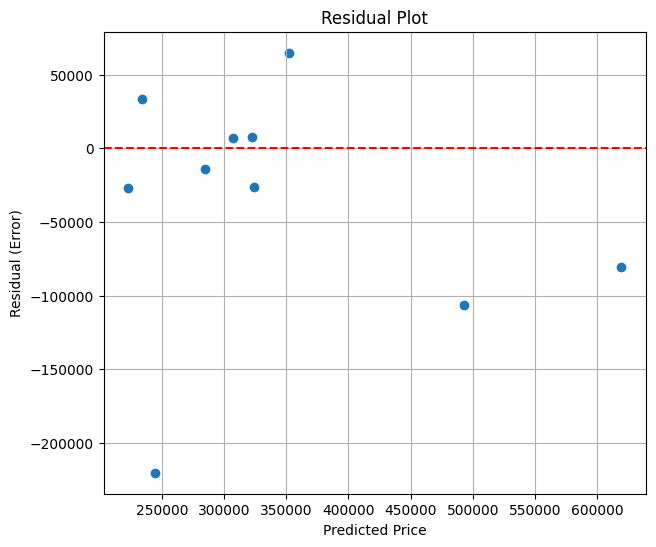

In [36]:
residuals = y_test_pred - y_test

plt.figure(figsize=(7,6))
plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


### Cross Validation

In [37]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores per fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())
print("Std Dev:", rmse_scores.std())


RMSE scores per fold: [47642.15147022 68272.82727073 97447.94779673 53349.71247396
 45425.60053956]
Average RMSE: 62427.64791024057
Std Dev: 19238.90307400234


### hyperplane visualization (copied from chatgpt)

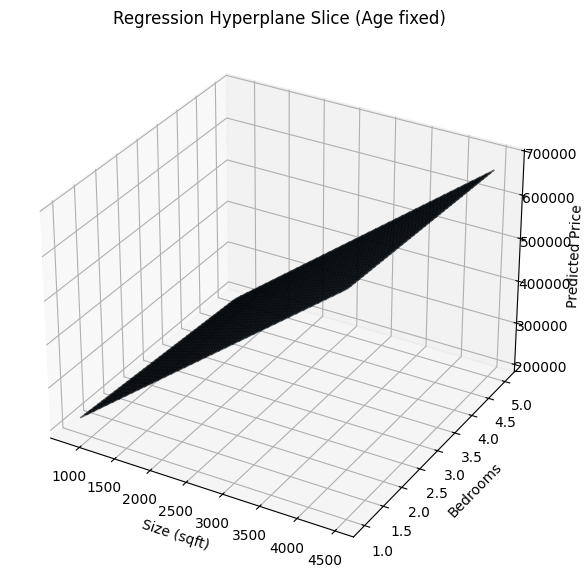

In [38]:
from mpl_toolkits.mplot3d import Axes3D

# we fix Age at a constant value
fixed_age = 10

# range for size
size_range = np.linspace(X[:,0].min(), X[:,0].max(), 40)

# range for bedrooms
bedroom_range = np.linspace(X[:,1].min(), X[:,1].max(), 40)

size_grid, bedroom_grid = np.meshgrid(size_range, bedroom_range)

# create grid for prediction
X_grid = np.column_stack([
    size_grid.ravel(),
    bedroom_grid.ravel(),
    np.full(size_grid.size, fixed_age)
])

# predict using pipeline
y_grid_pred = model.predict(X_grid).reshape(size_grid.shape)

# plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(size_grid, bedroom_grid, y_grid_pred, alpha=0.5, edgecolor='k')

ax.set_xlabel('Size (sqft)')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Predicted Price')

plt.title("Regression Hyperplane Slice (Age fixed)")
plt.show()
